# Tree-Based Classifier Comparison

This project compares Decision Tree, Random Forest and XGBoost classifiers on a nonlinear binary classification dataset. Hyperparameters are selected using a validation set, and final performance is assessed on a separate test set using accuracy and recall. Decision boundaries are visualised to compare how the models separate the classes.

This cell trains a decision tree classifier and selects the best hyperparameters using a validation set. The final model is then evaluated on a separate test dataset.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import train_test_split

from matplotlib.colors import ListedColormap
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import accuracy_score, recall_score

# Generate dataset
X, y = make_moons(n_samples = 300, noise = 0.25, random_state = 42)

# Split dataset into training and testing sets
# First split: training set and temporary set
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=1, stratify=y)

# Second split: validation set and test set
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp)

# Decision Tree Classifier

# Hyperparameters to tune
max_depth = [2, 5, 10]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 2, 5]

results = []
best_score = 0
best_clf = None

for m in max_depth:
    for s in min_samples_split:
        for l in min_samples_leaf:
            # Train the model using Decision Tree Classifier
            clf = DecisionTreeClassifier(
                max_depth=m,
                min_samples_split=s,
                min_samples_leaf=l,
                random_state=1
            )
            # Fit the model and predict
            clf.fit(X_train, y_train)
            pred = clf.predict(X_val)
            # Calculate accuracy score
            score = accuracy_score(y_val, pred)

            results.append((m, s, l, score))
            # Update best score and parameters
            if score > best_score:
                best_score = score
                best_clf = clf
                best_params = (m, s, l)
results = pd.DataFrame(results, columns=["max_depth", "min_samples_split", "min_samples_leaf", "accuracy_score"])
y_test_pred = best_clf.predict(X_test)
print("Validation accuracy:", best_score)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test recall:", recall_score(y_test, y_test_pred))

Validation accuracy: 0.8833333333333333
Test accuracy: 0.8833333333333333
Test recall: 0.9333333333333333


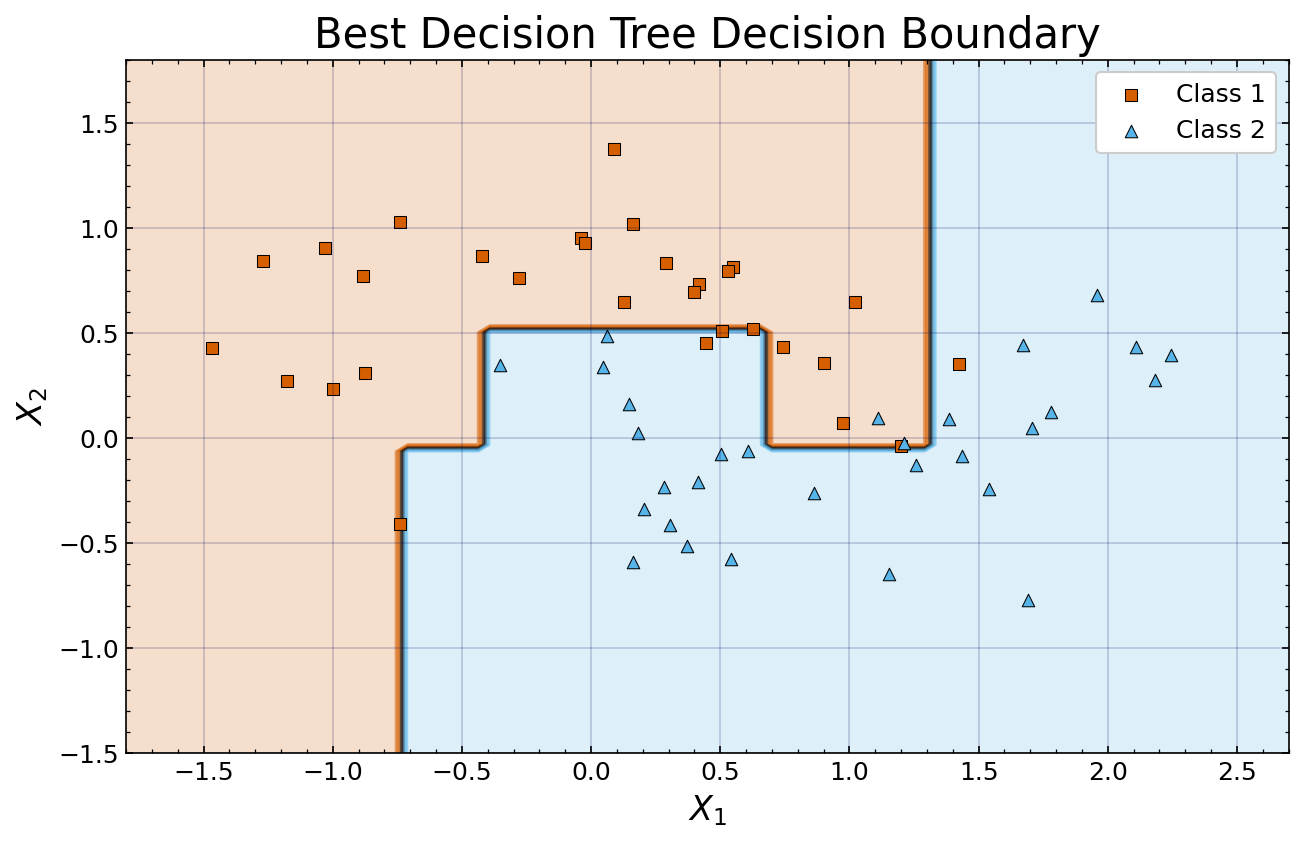

In [12]:
x1s = np.linspace(-1.8, 2.7, 100)
x2s = np.linspace(-1.5, 1.8, 100)
x1, x2 = np.meshgrid(x1s, x2s)

X_new = np.c_[x1.ravel(), x2.ravel()]
y_pred = best_clf.predict(X_new).reshape(x1.shape)

custom_cmap = ListedColormap(['#D55E00', 'black', '#56B4E9'])

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=150)
ax.contourf(x1, x2, y_pred, alpha=0.2, cmap=custom_cmap, zorder=0)
ax.contour(x1, x2, y_pred, cmap=custom_cmap, zorder=0, alpha=0.5)

ax.scatter(
    X_test[:, 0][y_test == 0],
    X_test[:, 1][y_test == 0],
    color='#D55E00',
    marker='s',
    label='Class 1',
    zorder=1,
    edgecolor='black',
    lw=0.5
)

ax.scatter(
    X_test[:, 0][y_test == 1],
    X_test[:, 1][y_test == 1],
    color='#56B4E9',
    marker='^',
    label='Class 2',
    zorder=1,
    edgecolor='black',
    lw=0.5
)

ax.set_xlabel('$X_1$', fontsize=16)
ax.set_ylabel('$X_2$', fontsize=16)
ax.tick_params(which='both', labelsize=12, direction='in', top=True, right=True)
ax.grid(color='xkcd:dark blue', alpha=0.2)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.legend(loc='upper right', fontsize=12, framealpha=1)
ax.set_title('Best Decision Tree Decision Boundary', fontsize=20)

plt.show()

This cell trains model using random forest classifier

In [13]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

max_depth = [2, 5, 10, 100]
min_samples_split = [2, 5, 10]
min_samples_leaf = [1, 5, 10]
n_estimators = [50, 100, 500, 1000]

results = []
best_score = 0
best_clf = None
for m in max_depth:
    for s in min_samples_split:
        for l in min_samples_leaf:
            for n in n_estimators:
                # Define model
                clf = RandomForestClassifier(n_estimators = n, max_depth = m, min_samples_leaf = l, min_samples_split = s, oob_score = True, random_state = 1)
                # Fit model
                clf.fit(X_train, y_train)
                # Predict on test data
                y_pred = clf.predict(X_val)
                score = accuracy_score(y_val, y_pred)
                if score > best_score:
                    best_score = score
                    best_clf = clf
                oob_score = clf.oob_score_
                results.append((m, s, l, n, score, oob_score))

results = pd.DataFrame(results, columns = ['max_depth', 'min_samples_split', 'min_samples_leaf', 'n_estimators', 'accuracy score', 'oob score'])

y_test_pred = best_clf.predict(X_test)

print("Validation accuracy:", best_score)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test recall:", recall_score(y_test, y_test_pred))
print('OOB Score:', best_clf.oob_score_)


Validation accuracy: 0.8833333333333333
Test accuracy: 0.9166666666666666
Test recall: 0.9333333333333333
OOB Score: 0.9222222222222223


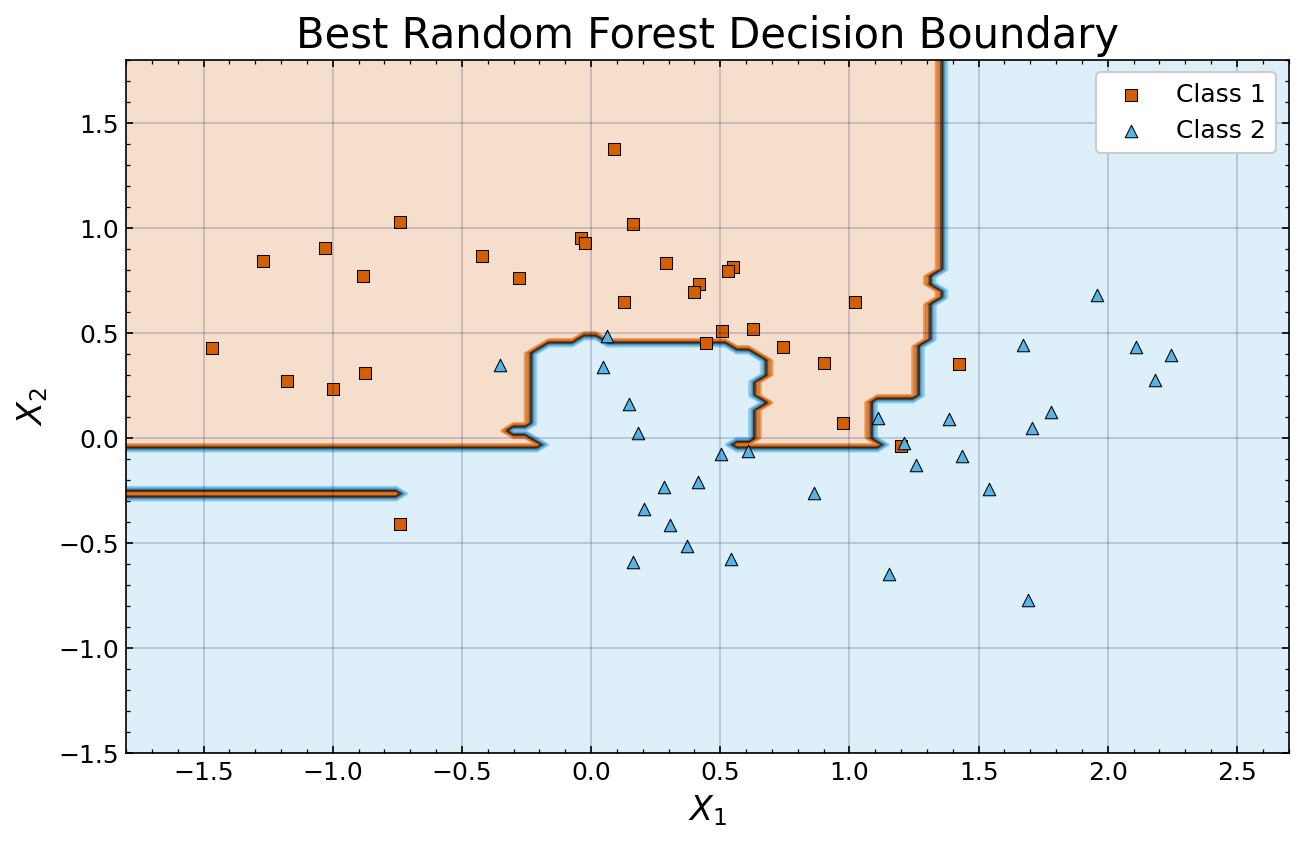

In [14]:
x1s, x2s = np.linspace(-1.8,2.7,100), np.linspace(-1.5,1.8,100)
x1, x2 = np.meshgrid(x1s, x2s)
X_new = np.c_[x1.ravel(), x2.ravel()]
y_pred = best_clf.predict(X_new).reshape(x1.shape)
custom_cmap = ListedColormap(['#D55E00','black','#56B4E9'])


fig, ax = plt.subplots(1,1,figsize = (10,6),dpi = 150)
ax.contourf(x1,x2,y_pred,alpha = 0.2, cmap = custom_cmap,zorder = 0)
ax.contour(x1,x2,y_pred,cmap = custom_cmap,zorder = 0, alpha = 0.5)
ax.scatter(X_test[:,0][y_test==0],X_test[:,1][y_test==0],color='#D55E00',marker='s',label= 'Class 1',zorder = 1,edgecolor='black',lw = 0.5)
ax.scatter(X_test[:,0][y_test==1],X_test[:,1][y_test==1],color='#56B4E9',marker='^',label='Class 2',zorder = 1,edgecolor='black',lw = 0.5)
ax.set_xlabel('$X_1$',fontsize = 16)
ax.set_ylabel('$X_2$',fontsize = 16)
ax.tick_params(which='both',labelsize= 12,direction='in',top=True,right=True)
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.legend(loc='upper right',fontsize = 12, framealpha = 1)
ax.set_title('Best Random Forest Decision Boundary',fontsize = 20)

plt.show()

This cell trains using XGBoost classifier

In [15]:
# XGBoost Classifier
from xgboost import XGBClassifier

n_estimators = [100, 500, 1000]
max_depth = [2, 5, 10  ]
max_leaves = [10, 20, 50]
learning_rate = [0.01, 0.1, 0.5]

results = []
best_score = 0
best_clf = None
for n in n_estimators:
    for d in max_depth:
        for l in max_leaves:
            for r in learning_rate:
                clf = XGBClassifier(n_estimators = n, max_depth = d, max_leaves = l, learning_rate = r, random_state = 1)
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_val)
                score = accuracy_score(y_val, y_pred)
                if score > best_score:
                    best_score = score
                    best_clf = clf
                results.append((n, d, l, r, score))
results = pd.DataFrame(results, columns = ['n_estimators', 'max_depth', 'max_leaves', 'learning_rate', 'accuracy score'])
y_test_pred = best_clf.predict(X_test)

print("Validation accuracy:", best_score)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test recall:", recall_score(y_test, y_test_pred))

Validation accuracy: 0.8833333333333333
Test accuracy: 0.9
Test recall: 0.9


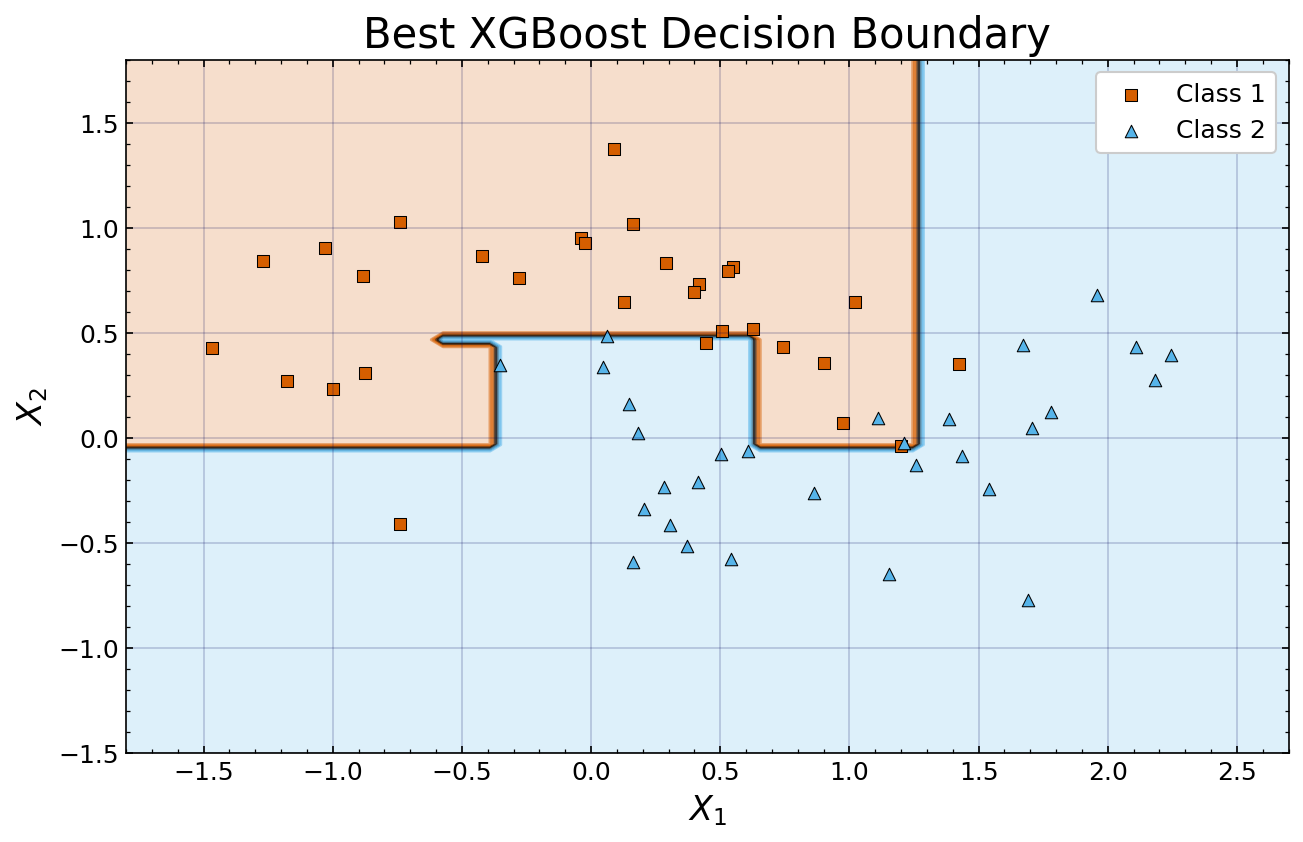

In [16]:
x1s, x2s = np.linspace(-1.8,2.7,100), np.linspace(-1.5,1.8,100)
x1, x2 = np.meshgrid(x1s, x2s)
X_new = np.c_[x1.ravel(), x2.ravel()]
y_pred = best_clf.predict(X_new).reshape(x1.shape)
custom_cmap = ListedColormap(['#D55E00','black','#56B4E9'])

fig, ax = plt.subplots(1,1,figsize = (10,6),dpi = 150)
ax.contourf(x1,x2,y_pred,alpha = 0.2, cmap = custom_cmap,zorder = 0)
ax.contour(x1,x2,y_pred,cmap = custom_cmap,zorder = 0, alpha = 0.5)
ax.scatter(X_test[:,0][y_test==0],X_test[:,1][y_test==0],color='#D55E00',marker='s',label= 'Class 1',zorder = 1,edgecolor='black',lw = 0.5)
ax.scatter(X_test[:,0][y_test==1],X_test[:,1][y_test==1],color='#56B4E9',marker='^',label='Class 2',zorder = 1,edgecolor='black',lw = 0.5)
ax.set_xlabel('$X_1$',fontsize = 16)
ax.set_ylabel('$X_2$',fontsize = 16)
ax.tick_params(which='both',labelsize= 12,direction='in',top=True,right=True)
ax.grid(color='xkcd:dark blue',alpha = 0.2)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))
ax.legend(loc='upper right',fontsize = 12, framealpha = 1)
ax.set_title('Best XGBoost Decision Boundary',fontsize = 20)

plt.show()